In [43]:
training_data_path = '/kaggle/input/datasets/uday1603/food-class/food_data/train'
validation_data_path = '/kaggle/input/datasets/uday1603/food-class/food_data/val'
testing_data_path = '/kaggle/input/datasets/uday1603/food-class/food_data/test'

In [44]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import json
from datetime import datetime
import cv2

In [45]:
os.listdir(testing_data_path)

['momos',
 'dhokla',
 'kaathi_rolls',
 'chole_bhature',
 'masala_dosa',
 'Donut',
 'Sandwich',
 'Hot Dog',
 'dal_makhani',
 'burger',
 'omelette',
 'Crispy Chicken',
 'cheesecake',
 'Fries',
 'chai',
 'chicken_curry',
 'chapati',
 'paani_puri',
 'pav_bhaji',
 'pakode',
 'ice_cream',
 'Baked Potato',
 'idli',
 'jalebi',
 'Taco',
 'kadai_paneer',
 'samosa',
 'sushi',
 'apple_pie',
 'butter_naan',
 'pizza',
 'Taquito',
 'kulfi',
 'fried_rice']

In [46]:
labels = ['Baked Potato', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Sandwich', 'Taco', 'Taquito', 'apple_pie', 'burger', 'butter_naan', 'chai', 'chapati', 'cheesecake', 'chicken_curry', 'chole_bhature', 'dal_makhani', 'dhokla', 'fried_rice', 'ice_cream', 'idli', 'jalebi', 'kaathi_rolls', 'kadai_paneer', 'kulfi', 'masala_dosa', 'momos', 'omelette', 'paani_puri', 'pakode', 'pav_bhaji', 'pizza', 'samosa', 'sushi']

In [47]:
train_data_rules = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_data_rules = ImageDataGenerator(rescale=1./255)
test_data_rules = ImageDataGenerator(rescale=1./255)


In [48]:
# Flow From Directory
final_train_data = train_data_rules.flow_from_directory(
    training_data_path,
    classes=labels,
    target_size=(256, 256),
    class_mode='categorical',
    batch_size=50,
    shuffle=True
)

final_val_data = val_data_rules.flow_from_directory(
    validation_data_path,
    classes=labels,
    target_size=(256, 256),
    class_mode='categorical',
    shuffle=False
)

final_test_data = test_data_rules.flow_from_directory(
    testing_data_path,
    classes=labels,
    target_size=(256, 256),
    class_mode='categorical',
    shuffle=False
)

Found 6800 images belonging to 34 classes.
Found 1700 images belonging to 34 classes.
Found 340 images belonging to 34 classes.


In [49]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = final_train_data.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0), 11: np.float64(1.0), 12: np.float64(1.0), 13: np.float64(1.0), 14: np.float64(1.0), 15: np.float64(1.0), 16: np.float64(1.0), 17: np.float64(1.0), 18: np.float64(1.0), 19: np.float64(1.0), 20: np.float64(1.0), 21: np.float64(1.0), 22: np.float64(1.0), 23: np.float64(1.0), 24: np.float64(1.0), 25: np.float64(1.0), 26: np.float64(1.0), 27: np.float64(1.0), 28: np.float64(1.0), 29: np.float64(1.0), 30: np.float64(1.0), 31: np.float64(1.0), 32: np.float64(1.0), 33: np.float64(1.0)}


In [50]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)


In [51]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Load Pretrained ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Custom Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(34, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [52]:
# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 24,157,730 (92.15 MB)

 Trainable params: 565,922 (2.16 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [54]:
history = model.fit(
    final_train_data,
    epochs=30,
    validation_data=final_val_data
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1771414239.807503     153 service.cc:152] XLA service 0x7da9ec003500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771414239.807546     153 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771414239.807553     153 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771414241.787154     153 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/136 ━━━━━━━━━━━━━━━━━━━━ 40:52 18s/step - accuracy: 0.0000e+00 - loss: 4.0037

I0000 00:00:1771414249.695232     153 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


127/136 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.0375 - loss: 3.7870

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


136/136 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - accuracy: 0.0376 - loss: 3.7799 - val_accuracy: 0.0406 - val_loss: 3.5342
Epoch 2/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.0412 - loss: 3.5688 - val_accuracy: 0.0553 - val_loss: 3.4896
Epoch 3/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.0489 - loss: 3.5034 - val_accuracy: 0.0924 - val_loss: 3.4483
Epoch 4/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.0529 - loss: 3.4812 - val_accuracy: 0.1141 - val_loss: 3.3988
Epoch 5/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.0692 - loss: 3.4408 - val_accuracy: 0.1112 - val_loss: 3.3562
Epoch 6/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.0758 - loss: 3.4171 - val_accuracy: 0.1165 - val_loss: 3.3187
Epoch 7/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.0723 - loss: 3.4073 - val_accuracy: 0.1200 - val_loss: 3.2912
Epoch 8/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.0762 - loss: 3.3881 - val_accuracy: 0.128

In [65]:
# Save model in Kaggle working directory
model.save("/kaggle/working/ResNet50.keras")
model.save("/kaggle/working/ResNet50.h5")

print("✅ ResNet50 model saved successfully in Kaggle working directory")


✅ ResNet50 model saved successfully in Kaggle working directory


In [57]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

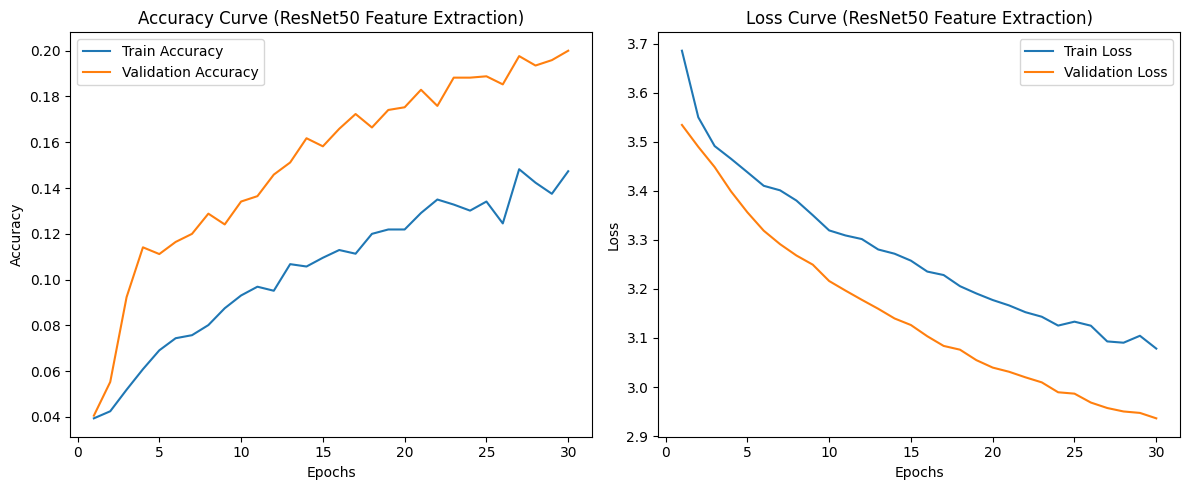

In [61]:
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve (ResNet50 Feature Extraction)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve (ResNet50 Feature Extraction)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [62]:
import numpy as np
import json
from datetime import datetime
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# ---------------- Reset Test Generator ----------------
final_test_data.reset()

# ---------------- Predictions ----------------
y_true = final_test_data.classes
y_pred_probs = model.predict(final_test_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# ---------------- Overall Multi-Class Metrics ----------------
overall_accuracy = accuracy_score(y_true, y_pred)
overall_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
overall_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
overall_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("Overall Accuracy :", round(float(overall_accuracy), 4))
print("Overall Precision:", round(float(overall_precision), 4))
print("Overall Recall   :", round(float(overall_recall), 4))
print("Overall F1 Score :", round(float(overall_f1), 4))


# ---------------- One-vs-Rest Per-Label Metrics ----------------
def per_label_binary_metrics(y_true, y_pred, target_index):

    # 1 = target class, 0 = others
    y_true_binary = np.array([1 if t == target_index else 0 for t in y_true])
    y_pred_binary = np.array([1 if p == target_index else 0 for p in y_pred])

    cm = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1])

    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    accuracy = accuracy_score(y_true_binary, y_pred_binary)

    return {
        "accuracy": round(float(accuracy), 4),
        "precision": round(float(precision), 4),
        "recall": round(float(recall), 4),
        "f1_score": round(float(f1), 4),
        "confusion_matrix_2x2": cm.tolist()
    }


label_wise_metrics = {}

for idx, label in enumerate(labels):
    label_wise_metrics[label] = per_label_binary_metrics(y_true, y_pred, idx)


# ---------------- JSON Structure ----------------
result_json = {
    "model_name": "ResNet50",
    "input_size": "256x256",
    "num_classes": 34,

    "overall_metrics": {
        "accuracy": round(float(overall_accuracy), 4),
        "precision": round(float(overall_precision), 4),
        "recall": round(float(overall_recall), 4),
        "f1_score": round(float(overall_f1), 4)
    },

    "labels": labels,
    "label_wise_metrics": label_wise_metrics,
    "generated_at": datetime.now().isoformat()
}

# ---------------- Save in Kaggle ----------------
json_path = "/kaggle/working/ResNet50_binary_metrics.json"

with open(json_path, "w") as f:
    json.dump(result_json, f, indent=4)

print("✅ ResNet50 JSON saved successfully in Kaggle working directory")


11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step 
Overall Accuracy : 0.2265
Overall Precision: 0.2352
Overall Recall   : 0.2265
Overall F1 Score : 0.2004
✅ ResNet50 JSON saved successfully in Kaggle working directory


Predicted Class : Crispy Chicken
Confidence      : 7.66 %


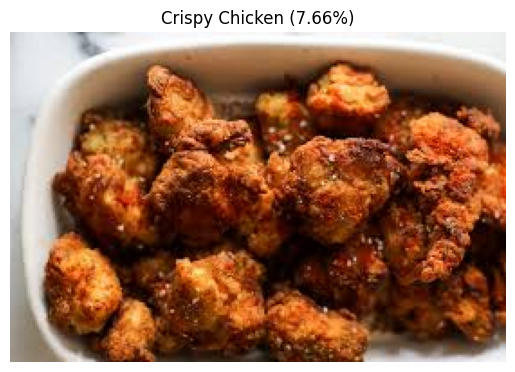

In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_own_image(path):

    # Check file
    img = cv2.imread(path)
    if img is None:
        print("❌ Image not found. Check file path.")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize SAME as training
    img_resized = cv2.resize(img, (256,256))

    # Normalize same as ImageDataGenerator(rescale=1./255)
    img_array = img_resized.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0])

    print("Predicted Class :", labels[predicted_class])
    print("Confidence      :", round(float(confidence)*100,2), "%")

    # Display
    plt.imshow(img)
    plt.title(f"{labels[predicted_class]} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()


predict_own_image("/kaggle/input/datasets/uday1603/food-class/food_data/test/Crispy Chicken/Crispy Chicken-Train (1065).jpeg")

In [66]:
import pickle
from tensorflow.keras.models import load_model

# Load the saved keras model
model_loaded = load_model("/kaggle/working/ResNet50.keras")

# Save as pickle
with open("/kaggle/working/ResNet50.pkl", "wb") as f:
    pickle.dump(model_loaded, f)

print("✅ Model also saved as ResNet50.pkl")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Model also saved as ResNet50.pkl
